## Architecture Overview:
The architecture consists of three main components, a visual backbone, a tabular encoder, and a cross-attention fusion module. An input image is processed by a Swin Transformer to produce a sequence of visual tokens representing different image regions.Tabular data is encoded using an MLP and projected into the same embedding space as the visual tokens. In the cross-attention module, the tabular representation serves as the Query (Q), while the visual tokens act as both Keys (K) and Values (V). This allows the tabular query to attend over image regions, computing attention weights that determine which visual features are most relevant. The weighted combination of Values produces a fused representation that captures modality interactions. This representation is normalized and passed through a fully connected prediction head to produce the final scalar output.

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
import sys
sys.path.insert(0, os.path.abspath("../.."))

In [4]:
# Cell 1: imports & setup
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc

gc.enable()

import torch


from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config




main_folder = "../.."
data_csv = os.path.join(main_folder, "data", "train.csv")
img_folder = os.path.join(main_folder, "data", "train")
out_dir = os.path.join(main_folder, "outputs","extra", "exp13_swin_cross_attn_mse_loss")

df = pd.read_csv(data_csv)
cfg = EXP_CONFIGS["exp13_cross_attn"]   # define in config
cfg["name"] = "exp13_swin_cross_attn_mse_loss"
cfg["loss"] = "mse"  #

TARGET = "Pawpularity"
tab_cols = [c for c in df.columns if c not in ["Id", TARGET]]

os.makedirs(out_dir, exist_ok=True)
save_config(cfg, out_dir)
set_seed(cfg["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
oof_pred = np.zeros(len(df))
oof_true = df[TARGET].values
fold_index = np.full(len(df), -1, dtype=int)
fold_rmse = []

start_all = time.time()
for fold, (tr_idx, val_idx) in enumerate(kf.split(df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    best_rmse, val_preds, val_targets, val_ids = run_single_fold(
    fold=fold,
    train_df=train_df,
    val_df=val_df,
    img_folder=img_folder,
    cfg=cfg,
    out_dir=out_dir,
    device=device,
    mode="cross_attn_swin",    
    tab_cols=tab_cols,
    workers=16,
    pin_memory=True,
    persistent_workers=True,
    freeze_backbone=False,              # False => finetune EfficientNet-B1,True -> Freezen backbone entirely
    # cross-attention specific
    cross_attn_num_heads=8,
    cross_attn_query_mode="tab_queries_image",  #Q->tabular_embed, K&V = visual_tokens
    cross_attn_dropout=0.1,
)

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")

all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")
# final metrics + OOF with fold column
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)
print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": df["Id"],
    "fold": fold_index,     
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)
oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)
with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")


/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



=== exp13_swin_cross_attn_mse_loss: Fold 1 ===
Epoch 1/10 | Fold 1 | Train[MSE]: RMSE=24.8246 | ValRMSE: 21.1562
Epoch 2/10 | Fold 1 | Train[MSE]: RMSE=19.6790 | ValRMSE: 18.6586
Epoch 3/10 | Fold 1 | Train[MSE]: RMSE=18.0399 | ValRMSE: 19.0985
Epoch 4/10 | Fold 1 | Train[MSE]: RMSE=16.9169 | ValRMSE: 18.7130
Epoch 5/10 | Fold 1 | Train[MSE]: RMSE=15.7545 | ValRMSE: 17.7142
Epoch 6/10 | Fold 1 | Train[MSE]: RMSE=14.5243 | ValRMSE: 17.9087
Epoch 7/10 | Fold 1 | Train[MSE]: RMSE=13.4698 | ValRMSE: 18.3610
Epoch 8/10 | Fold 1 | Train[MSE]: RMSE=12.6421 | ValRMSE: 18.4817
Epoch 9/10 | Fold 1 | Train[MSE]: RMSE=12.0078 | ValRMSE: 18.5715
Epoch 10/10 | Fold 1 | Train[MSE]: RMSE=11.7412 | ValRMSE: 18.7138
Early stopping at epoch 10
Fold 1 best RMSE: 17.7142

=== exp13_swin_cross_attn_mse_loss: Fold 2 ===
Epoch 1/10 | Fold 2 | Train[MSE]: RMSE=24.1875 | ValRMSE: 20.5919
Epoch 2/10 | Fold 2 | Train[MSE]: RMSE=19.8015 | ValRMSE: 18.9106
Epoch 3/10 | Fold 2 | Train[MSE]: RMSE=18.2063 | ValRMSE: 

In [5]:

import pandas as pd
df = pd.read_csv(out_dir+"/oof_detail.csv")
fold_rmse = []

for fold in range(1, 6):
    sub = df[df.fold == fold]
    rmse = ((sub.ytrue - sub.oof_pred)**2).mean() ** 0.5
    fold_rmse.append(rmse)
    print(f"Fold {fold} OOF RMSE: {rmse:.4f} (n={len(sub)})")

Fold 1 OOF RMSE: 17.7142 (n=1983)
Fold 2 OOF RMSE: 17.9353 (n=1983)
Fold 3 OOF RMSE: 17.4594 (n=1982)
Fold 4 OOF RMSE: 17.8334 (n=1982)
Fold 5 OOF RMSE: 18.2974 (n=1982)


### Train and Validation RMSE Curve

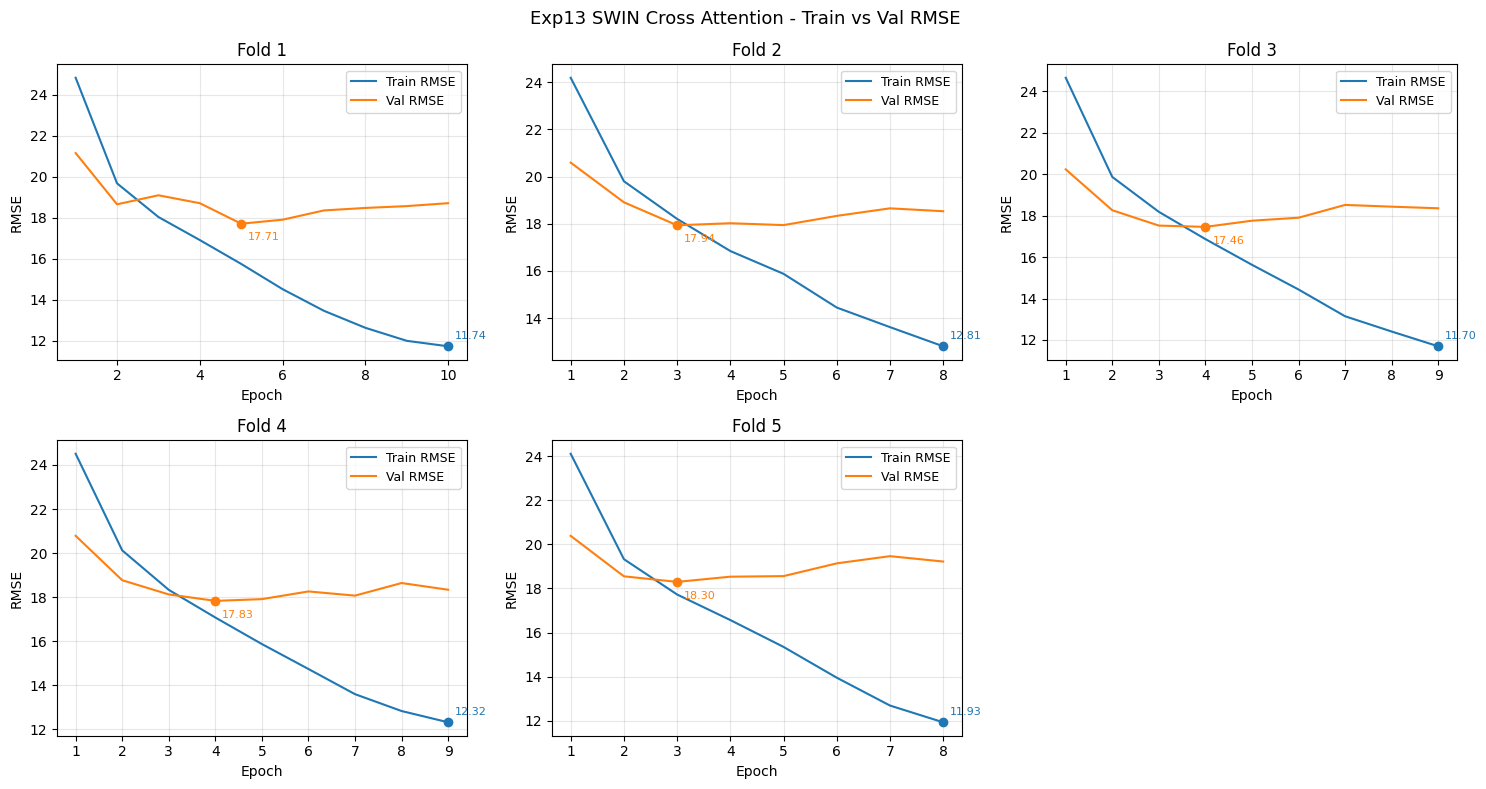

In [6]:
from src.plot import plot_train_val_history
plot_train_val_history(out_dir, folds=[1,2,3,4,5], title_prefix="Exp13 SWIN Cross Attention")

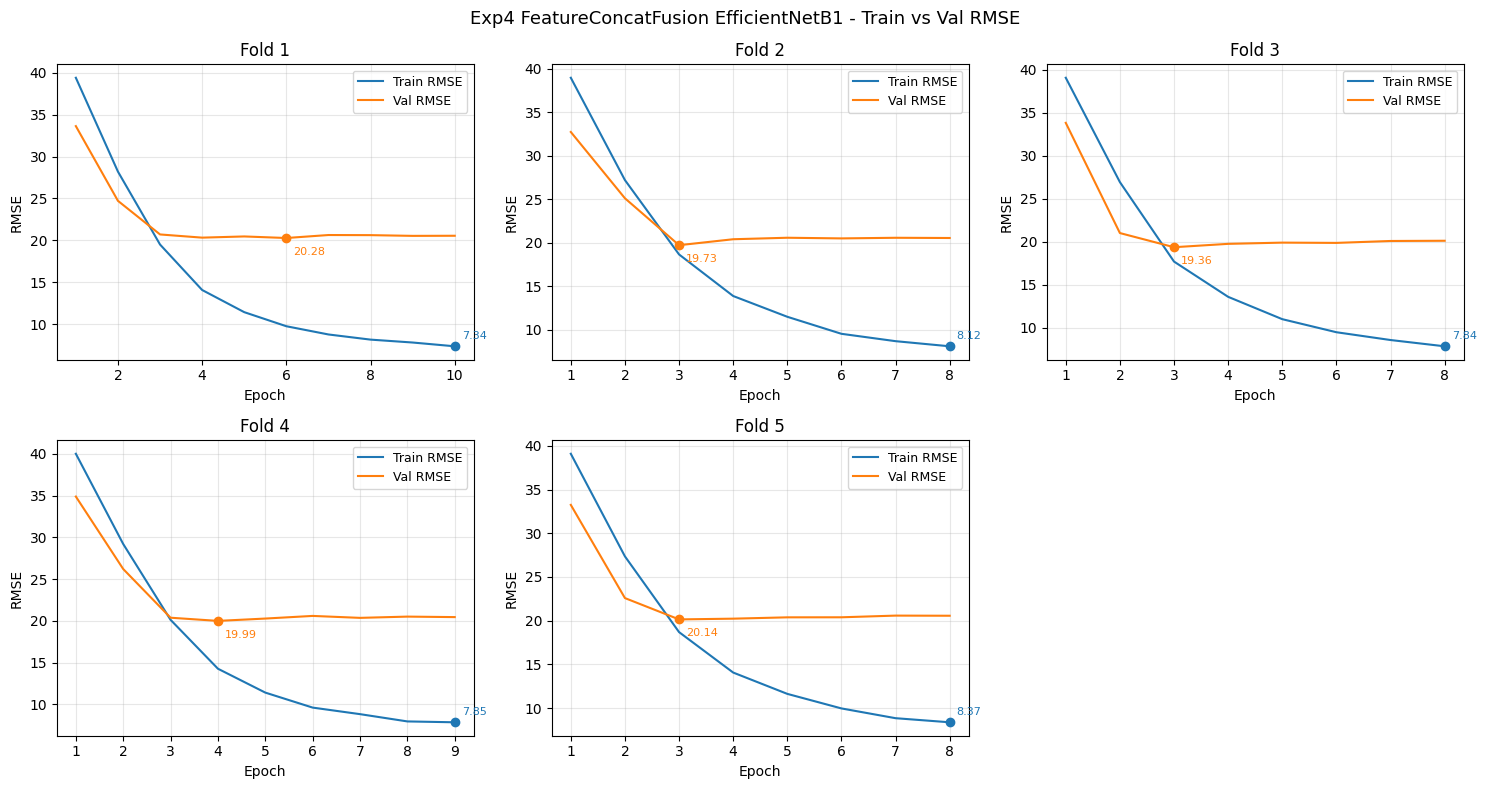

In [9]:
from src.plot import plot_train_val_history
out_dir1 = os.path.join("../..", "outputs", "exp4")
plot_train_val_history(out_dir1, folds=[1,2,3,4,5], title_prefix="Exp4 FeatureConcatFusion EfficientNetB1")

### Side by Side Comparison with Concatenation based Feature Fusion Exp4

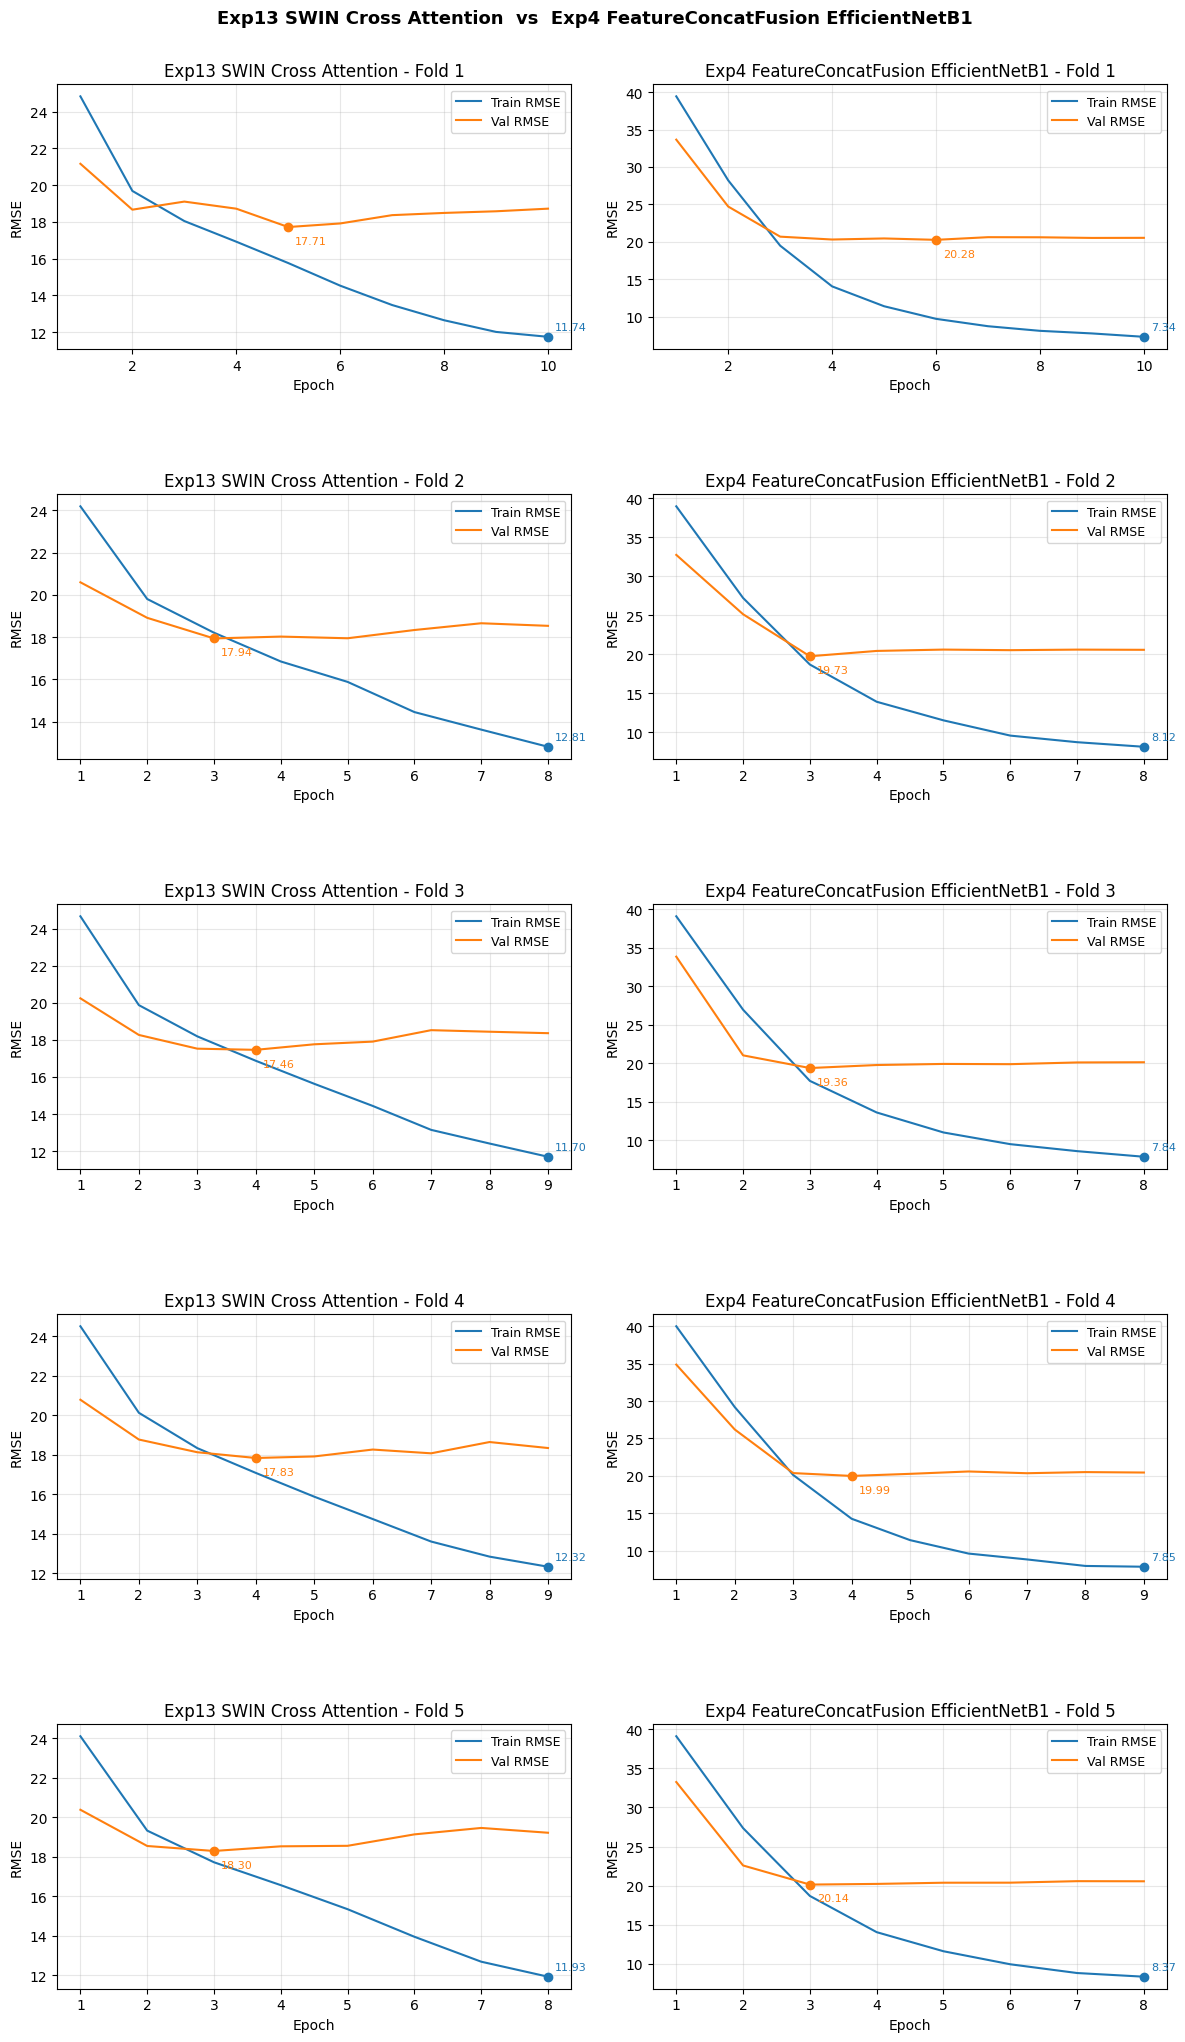

In [10]:
from src.plot import plot_compare_two_experiments
plot_compare_two_experiments(out_dir, out_dir1,folds=[1,2,3,4,5], label_a="Exp13 SWIN Cross Attention", label_b="Exp4 FeatureConcatFusion EfficientNetB1")

In [11]:
#  Inspect worst error rows

errors_path = os.path.join(out_dir, "top50_errors.csv")
err_df = pd.read_csv(errors_path)
err_df.head()

,Id,fold,ytrue,oof_pred,abs_err
0,4435d6f98ad72782ca0cf61f946b016d,5,100,26.496992,73.503008
1,d68d07de825adcadc895c52626d7b55f,5,100,28.052206,71.947794
2,f7903a7d6be4a636f8c28fd23b4951ec,4,100,28.142601,71.857399
3,e638853bdec13e6cc76b69f169b34740,4,96,24.518738,71.481262
4,6dcb7396e06ee6a538522d2f67f017db,5,100,28.537323,71.462677


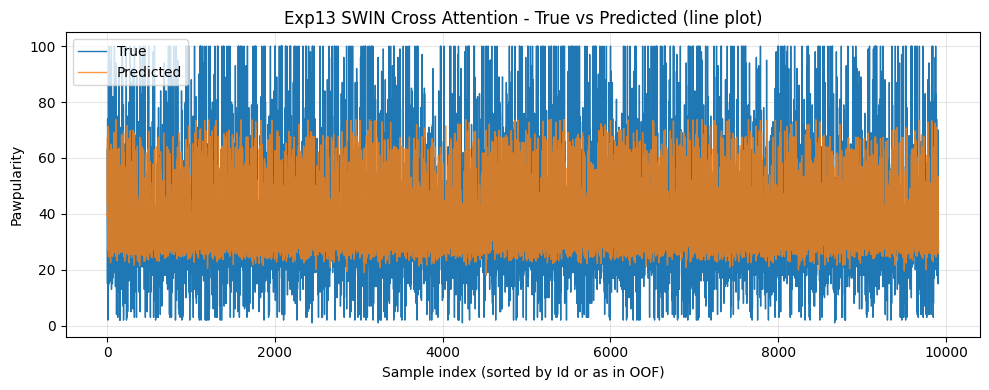

In [12]:
import os
import pandas as pd
from src.plot import (
   plot_oof_true_pred_lines,
    show_images_grid,
)

# Load OOF detail and top-errors
oof_df = pd.read_csv(os.path.join(out_dir, "oof_detail.csv"))
err_df = pd.read_csv(os.path.join(out_dir, "top50_errors.csv"))

# Plot
plot_oof_true_pred_lines(oof_df, title_prefix="Exp13 SWIN Cross Attention")





Exp13 SWIN Cross Attention OOF RMSE: 17.850055716886025
Exp4_FeatureConcat EffB1 Fusion OOF RMSE: 19.90331621767278
ΔRMSE (Exp4_FeatureConcat EffB1 Fusion - Exp13 SWIN Cross Attention): 2.053260500786756


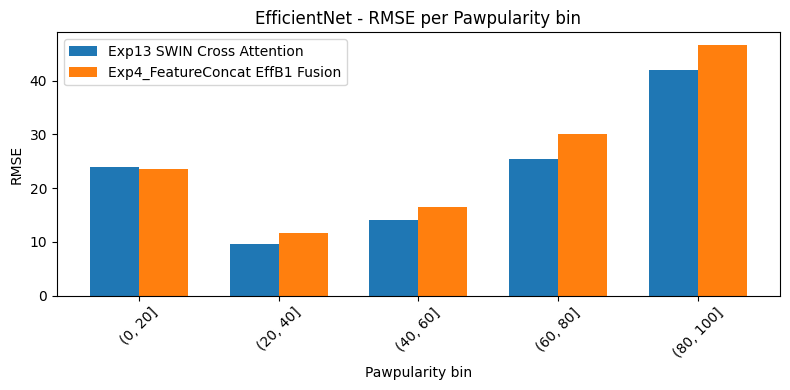

In [13]:
from src.plot import compare_oof_by_bins
bins = [0, 20, 40, 60, 80, 100]

df_bins, rmse3_all, rmse5_all, gap = compare_oof_by_bins(
    oof_path_a=os.path.join(out_dir, "oof_detail.csv"),
    oof_path_b=os.path.join(out_dir1, "oof_detail.csv"),
    bins=bins,
    label_a="Exp13 SWIN Cross Attention",
    label_b="Exp4_FeatureConcat EffB1 Fusion",
    title_prefix="EfficientNet",
)

In [14]:
df_bins.head()

,bin,count,Exp13 SWIN Cross Attention_rmse,Exp4_FeatureConcat EffB1 Fusion_rmse,rmse_diff,winner
0,"(0, 20]",1417,23.974934,23.561754,-0.413180,Exp4_FeatureConcat EffB1 Fusion_better
1,"(20, 40]",5119,9.664146,11.605182,1.941035,Exp13 SWIN Cross Attention_better
2,"(40, 60]",2088,14.010409,16.538259,2.527850,Exp13 SWIN Cross Attention_better
3,"(60, 80]",727,25.475701,30.127592,4.651891,Exp13 SWIN Cross Attention_better
4,"(80, 100]",561,41.879574,46.623998,4.744424,Exp13 SWIN Cross Attention_better


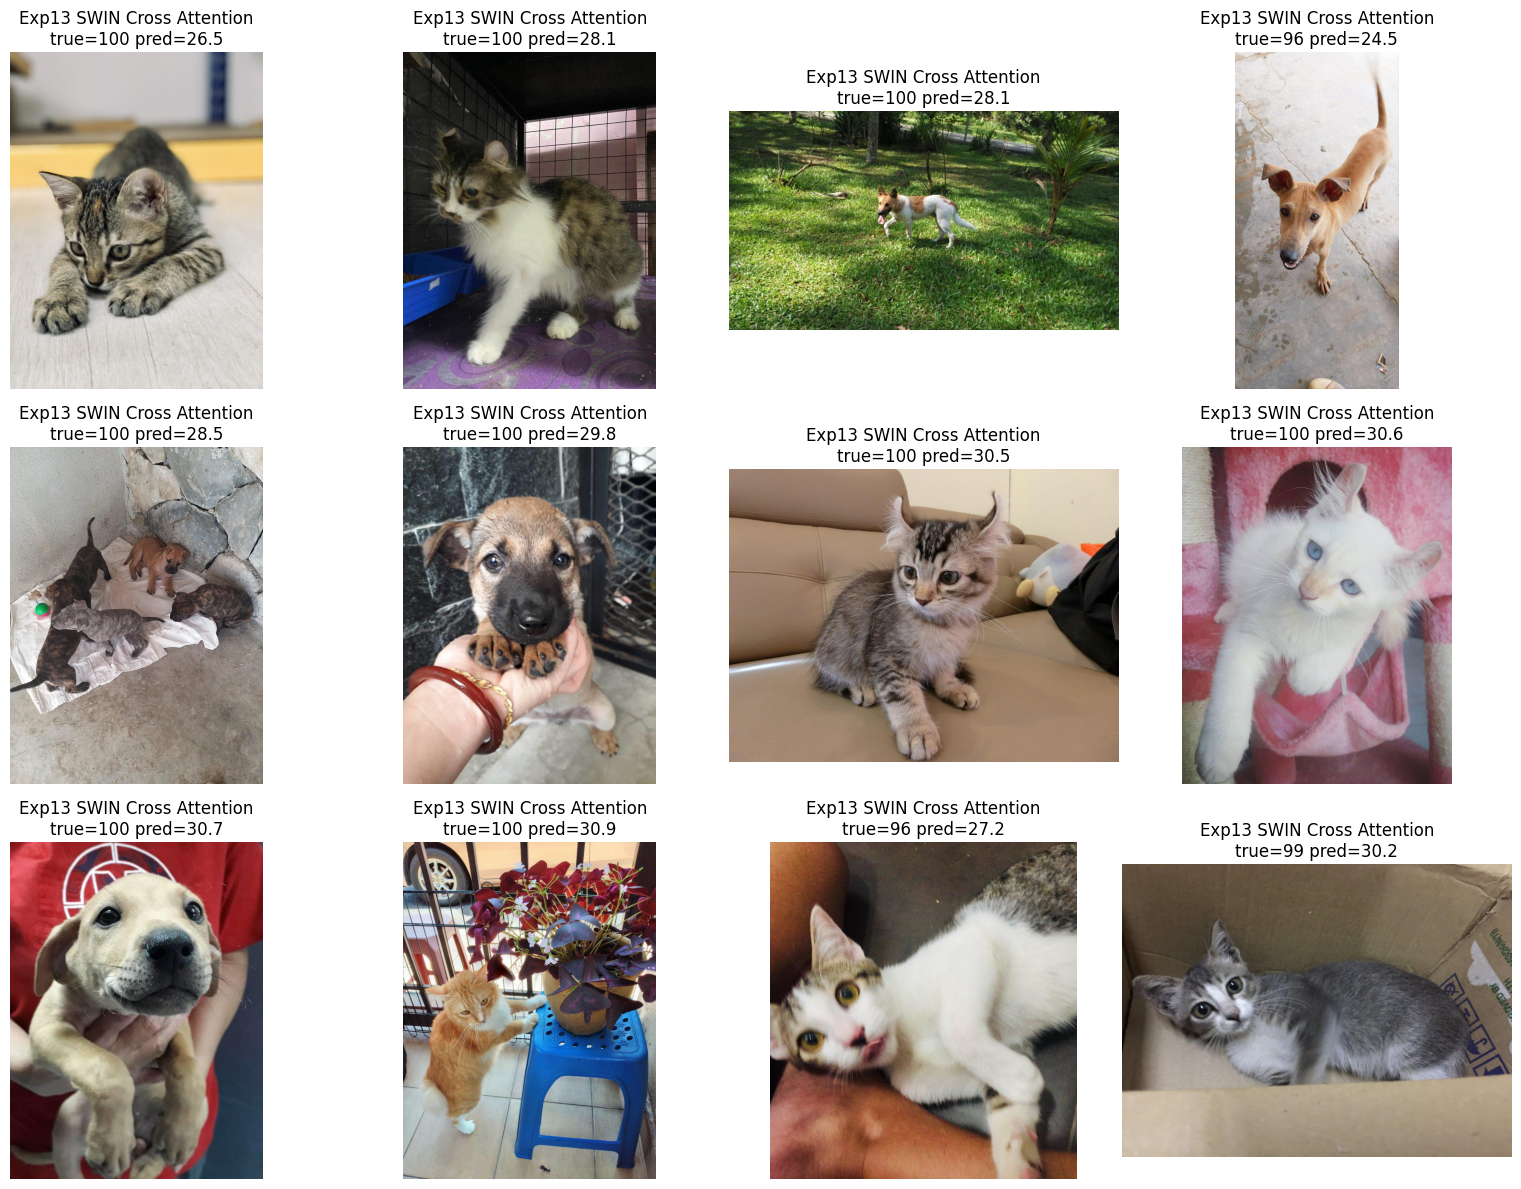

In [15]:
# Images of worst errors of FiLM 12 experiment
img_folder = os.path.join(main_folder, "data", "train")
show_images_grid(err_df, img_folder, n=12, title_prefix="Exp13 SWIN Cross Attention")

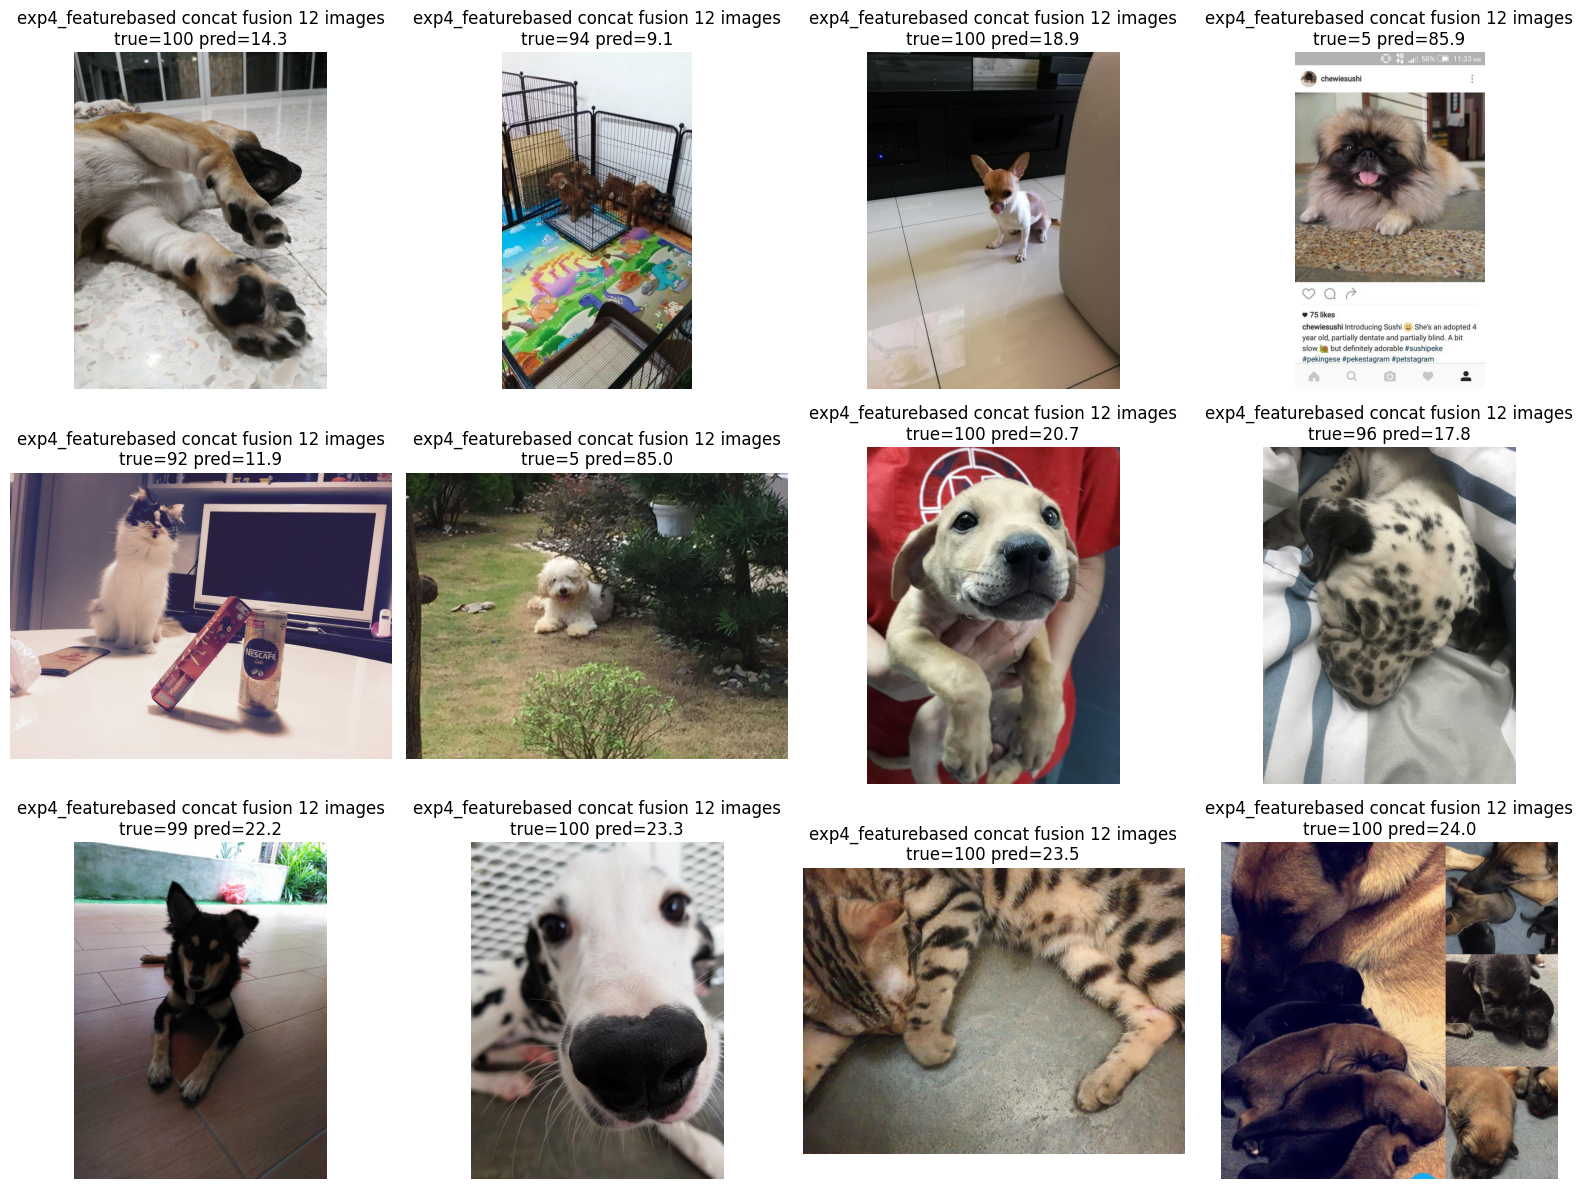

In [16]:

# Load OOF detail and top-errors of Exp4 
oof_df1 = pd.read_csv(os.path.join(out_dir1, "oof_detail.csv"))
err_df1 = pd.read_csv(os.path.join(out_dir1, "top50_errors.csv"))
show_images_grid(err_df1, img_folder, n=12, title_prefix="exp4_featurebased concat fusion 12 images")